Graphviz und Pandas sind verfügbar.


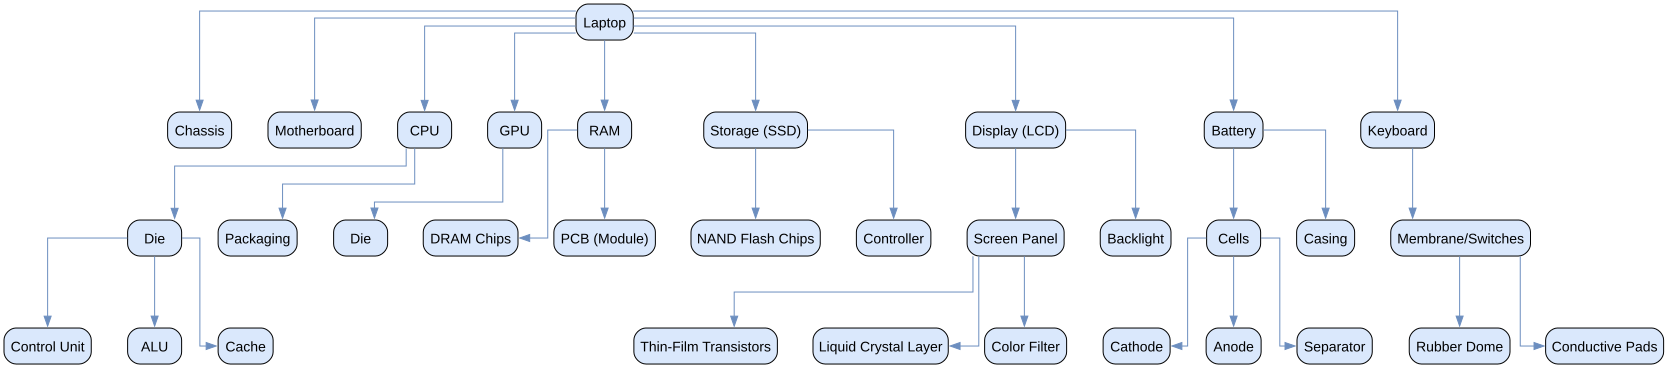

In [2]:
import pandas as pd
import graphviz
import os

# Test, ob der Import funktioniert hat
print("Graphviz und Pandas sind verfügbar.")

# 1. Datenstruktur
data = {
    'ID': [
        'Laptop', 'Chassis', 'Motherboard', 'CPU', 'GPU', 'RAM', 'Storage', 'Display', 'Battery', 'Keyboard',
        'Die_CPU', 'Packaging_CPU', 'Die_GPU', 'DRAM_Chips', 'PCB_Module_RAM', 'NAND_Chips', 'Controller_SSD',
        'Panel_LCD', 'Backlight_LCD', 'Cells_Battery', 'Casing_Battery', 'Switches_Keyboard',
        'ControlUnit_CPU', 'ALU_CPU', 'Cache_CPU', 'TFT_Display', 'LiquidCrystal_Display', 'ColorFilter_Display',
        'Cathode_Battery', 'Anode_Battery', 'Separator_Battery', 'RubberDome_Keyboard', 'ConductivePads_Keyboard'
    ],
    'Name': [
        'Laptop', 'Chassis', 'Motherboard', 'CPU', 'GPU', 'RAM', 'Storage (SSD)', 'Display (LCD)', 'Battery', 'Keyboard',
        'Die', 'Packaging', 'Die', 'DRAM Chips', 'PCB (Module)', 'NAND Flash Chips', 'Controller',
        'Screen Panel', 'Backlight', 'Cells', 'Casing', 'Membrane/Switches',
        'Control Unit', 'ALU', 'Cache', 'Thin-Film Transistors', 'Liquid Crystal Layer', 'Color Filter',
        'Cathode', 'Anode', 'Separator', 'Rubber Dome', 'Conductive Pads'
    ],
    'Parent': [
        None, 'Laptop', 'Laptop', 'Laptop', 'Laptop', 'Laptop', 'Laptop', 'Laptop', 'Laptop', 'Laptop',
        'CPU', 'CPU', 'GPU', 'RAM', 'RAM', 'Storage', 'Storage',
        'Display', 'Display', 'Battery', 'Battery', 'Keyboard',
        'Die_CPU', 'Die_CPU', 'Die_CPU', 'Panel_LCD', 'Panel_LCD', 'Panel_LCD',
        'Cells_Battery', 'Cells_Battery', 'Cells_Battery', 'Switches_Keyboard', 'Switches_Keyboard'
    ]
}
df = pd.DataFrame(data)

# 2. Graphviz-Objekt initialisieren
dot = graphviz.Digraph('Laptop_BOM', comment='Bill of Materials für einen Laptop')
dot.attr(rankdir='TB', splines='ortho', nodesep='0.5', ranksep='1')
dot.attr('node', shape='box', style='rounded,filled', fillcolor='#dae8fc', fontname='Arial')
dot.attr('edge', color='#6c8ebf')

# 3. Knoten und Kanten hinzufügen
for index, row in df.iterrows():
    dot.node(row['ID'], row['Name'])
    if pd.notna(row['Parent']):
        dot.edge(row['Parent'], row['ID'])

# 4. Graphen direkt im Jupyter Notebook anzeigen
# Wenn Sie in Jupyter arbeiten, wird das Objekt direkt als Grafik ausgegeben.
dot


In [3]:
def export_verbesserte_grafik(dataframe, dateiname='output_verbessert', format='png'):
    """Erstellt eine visuell verbesserte Grafik mit Farben und Clustern."""
    
    # Hierarchie-Ebenen für Farbkodierung definieren
    level_colors = {
        0: '#0d47a1',  # Level 0: Produkt
        1: '#1976d2',  # Level 1: Hauptkomponenten
        2: '#42a5f5',  # Level 2: Subkomponenten
        3: '#bbdefb'   # Level 3: Sub-Subkomponenten
    }
    
    # Erstelle eine Map von ID zu Parent
    parent_map = dataframe.set_index('ID')['Parent'].to_dict()

    def get_level(node_id):
        level = 0
        current = node_id
        while pd.notna(parent_map.get(current)):
            current = parent_map[current]
            level += 1
        return level

    # Graph-Initialisierung
    dot = graphviz.Digraph('Laptop_BOM_Verbessert')
    dot.attr(rankdir='TB', splines='ortho', compound='true') # compound=true ist für Cluster wichtig
    dot.attr('node', style='filled', fontname='Arial', fontcolor='white')
    dot.attr('edge', fontname='Arial', fontsize='10')

    # Gruppierung der Hauptkomponenten in Subgraphen (Cluster)
    for component_id in dataframe[dataframe['Parent'] == 'Laptop']['ID']:
        with dot.subgraph(name=f'cluster_{component_id}') as c:
            c.attr(label=dataframe[dataframe['ID'] == component_id]['Name'].iloc[0], style='filled', color='#eeeeee', fontname='Arial')
            # Fülle den Cluster mit den untergeordneten Knoten
            children = dataframe[dataframe['Parent'] == component_id]['ID']
            for child_id in children:
                 # Hier könnten rekursiv weitere Kinder hinzugefügt werden
                 c.node(child_id, dataframe[dataframe['ID'] == child_id]['Name'].iloc[0])


    # Alle Knoten und Kanten hinzufügen und färben
    for _, row in dataframe.iterrows():
        level = get_level(row['ID'])
        color = level_colors.get(level, '#9e9e9e')
        font_color = 'white' if level < 2 else 'black'
        dot.node(row['ID'], row['Name'], shape='box', rounded='1', fillcolor=color, fontcolor=font_color)
        
        if pd.notna(row['Parent']):
            # Kantenlabel hinzufügen (z.B. "enthält")
            dot.edge(row['Parent'], row['ID'], label='enthält')
            
    try:
        dot.render(dateiname, format=format, view=True, cleanup=True)
        print(f"Verbesserte Grafik erfolgreich als '{dateiname}.{format}' gespeichert.")
    except graphviz.backend.ExecutableNotFound:
        print("Fehler: Graphviz wurde nicht gefunden.")

# Anwendung der verbesserten Funktion
export_verbesserte_grafik(df)

Verbesserte Grafik erfolgreich als 'output_verbessert.png' gespeichert.


In [4]:
import graphviz

def erstelle_lvp_fliessenbild(dateiname='LVP_Sortieranlage', format='png'):
    """
    Erstellt ein Prozessfließbild für eine LVP-Sortieranlage mit Graphviz.
    """
    # 1. Initialisierung des Digraph-Objekts
    # rankdir='LR' sorgt für ein klassisches Links-nach-Rechts-Fließbild.
    dot = graphviz.Digraph('LVP Sortieranlage', comment='Prozessfließbild')
    dot.attr(rankdir='LR', splines='ortho', nodesep='0.6', ranksep='1.2')
    
    # 2. Definition von Styles für verschiedene Knotentypen
    # Dies macht den Code lesbarer und Änderungen einfacher.
    process_style = {'shape': 'box', 'style': 'rounded,filled', 'fillcolor': '#dae8fc', 'fontname': 'Arial'}
    input_output_style = {'shape': 'ellipse', 'style': 'filled', 'fillcolor': '#e8f5e9', 'fontname': 'Arial'}
    final_product_style = {'shape': 'cylinder', 'style': 'filled', 'fillcolor': '#fff3e0', 'fontname': 'Arial', 'label': 'Ballenpresse &\nProduktlager'}

    # 3. Knoten (Prozessschritte und I/O) erstellen
    # Wir verwenden die vorher definierten Styles.
    dot.node('input', 'LVP-Sammelware\n(Gelber Sack)', **input_output_style)
    dot.node('aufreisser', 'Sackaufreißer', **process_style)
    dot.node('sieb', 'Siebtrommel', **process_style)
    dot.node('windsichter', 'Windsichter', **process_style)
    dot.node('fe_abscheider', 'Magnetabscheider (FE)', **process_style)
    dot.node('ne_abscheider', 'Wirbelstromabscheider (NE)', **process_style)
    
    # Visuelle Gruppierung der NIR-Trenner (Kernprozess)
    with dot.subgraph(name='cluster_nir') as c:
        c.attr(label='NIR-Sortierkaskade', style='filled', color='#eeeeee', fontname='Arial')
        c.node('nir_pp', 'NIR-Trenner (PP)', **process_style)
        c.node('nir_pe', 'NIR-Trenner (PE)', **process_style)
        c.node('nir_pet', 'NIR-Trenner (PET)', **process_style)

    # Output-Knoten
    dot.node('output_fein', 'Feinanteil', **input_output_style)
    dot.node('output_folie', 'Folienfraktion (LDPE)', **input_output_style)
    dot.node('output_fe', 'FE-Metalle', **input_output_style)
    dot.node('output_ne', 'NE-Metalle', **input_output_style)
    dot.node('output_rest', 'Restfraktion\n(energet. Verwertung)', **input_output_style)

    # Produktlager-Knoten (Sammelpunkt für Wertstoffe)
    dot.node('lager_pp', **final_product_style)
    dot.node('lager_pe', **final_product_style)
    dot.node('lager_pet', **final_product_style)

    # 4. Kanten (Materialflüsse) definieren
    # Die 'label'-Attribute beschreiben den Materialstrom.
    dot.edge('input', 'aufreisser')
    dot.edge('aufreisser', 'sieb', label='geöffnetes Material')
    dot.edge('sieb', 'windsichter', label='Überkorn > 80mm')
    dot.edge('sieb', 'output_fein', label='Unterkorn < 80mm')
    dot.edge('windsichter', 'fe_abscheider', label='Schwerfraktion')
    dot.edge('windsichter', 'output_folie', label='Leichtfraktion (Folien)')
    dot.edge('fe_abscheider', 'ne_abscheider', label='nicht-magnetisch')
    dot.edge('fe_abscheider', 'output_fe')
    dot.edge('ne_abscheider', 'nir_pp', label='kunststoffreicher Strom')
    dot.edge('ne_abscheider', 'output_ne')

    # Kanten für die NIR-Kaskade
    dot.edge('nir_pp', 'nir_pe', label='Reststrom 1')
    dot.edge('nir_pe', 'nir_pet', label='Reststrom 2')
    dot.edge('nir_pet', 'output_rest', label='finaler Reststrom')
    
    # Produkt-Pfade
    dot.edge('nir_pp', 'lager_pp', label='PP-Fraktion')
    dot.edge('nir_pe', 'lager_pe', label='PE-Fraktion')
    dot.edge('nir_pet', 'lager_pet', label='PET-Fraktion')

    # 5. Rendern und Speichern
    try:
        dot.render(dateiname, format=format, view=True, cleanup=True)
        print(f"Fließbild erfolgreich als '{dateiname}.{format}' gespeichert.")
    except graphviz.backend.ExecutableNotFound:
        print("Fehler: Graphviz wurde nicht gefunden. Bitte Installation und PATH überprüfen.")

# Funktion aufrufen
erstelle_lvp_fliessenbild()

Fließbild erfolgreich als 'LVP_Sortieranlage.png' gespeichert.


In [6]:
# -*- coding: utf-8 -*-

# Benötigte Bibliotheken installieren:
pip install anytree
pip install graphviz

# Wichtiger Hinweis: Stellen Sie sicher, dass Graphviz auf Ihrem System installiert ist und 
# der Installationspfad zur Systemumgebungsvariable PATH hinzugefügt wurde.
# Download: https://graphviz.org/download/

from anytree import Node, RenderTree
from anytree.exporter import DotExporter
import os

def create_laptop_bom():
    """
    Erstellt die hierarchische Stücklistenstruktur für einen Laptop.

    Returns:
        Node: Der Wurzelknoten des BOM-Baums.
    """
    # Level 0: Endprodukt
    laptop = Node("Laptop 'CircularPro 15'")

    # Level 1: Hauptbaugruppen
    display_assembly = Node("1.0 Display-Baugruppe", parent=laptop)
    main_chassis = Node("2.0 Hauptgehäuse-Baugruppe", parent=laptop)
    battery_pack = Node("3.0 Akku-Pack", parent=laptop)
    power_supply = Node("4.0 Externes Netzteil & Kabel", parent=laptop)

    # Level 2: Unterbaugruppen und Hauptkomponenten für Display
    Node("1.1 LCD-Panel", parent=display_assembly)
    Node("1.2 Display-Gehäuse", parent=display_assembly)
    Node("1.3 Scharniere", parent=display_assembly)
    Node("1.4 Webcam-Modul", parent=display_assembly)

    # Level 2: Unterbaugruppen und Hauptkomponenten für Hauptgehäuse
    mlb = Node("2.1 Main Logic Board (MLB)", parent=main_chassis)
    Node("2.2 Kühlsystem", parent=main_chassis)
    Node("2.3 Top-Case mit Tastatur", parent=main_chassis)
    Node("2.4 Trackpad-Einheit", parent=main_chassis)
    Node("2.5 Lautsprecher", parent=main_chassis)
    Node("2.6 Bodenplatte", parent=main_chassis)

    # Level 3: Elektronische Schlüsselkomponenten auf dem MLB
    Node("2.1.1 CPU (verlötet)", parent=mlb)
    Node("2.1.2 RAM-Module (gesteckt)", parent=mlb)
    Node("2.1.3 SSD-Speicher (gesteckt)", parent=mlb)
    Node("2.1.4 Wi-Fi/BT-Modul", parent=mlb)
    
    # Level 3: Komponenten des Akku-Packs
    bms = Node("3.1 Batterie-Subsystem", parent=battery_pack)
    Node("3.1.1 Lithium-Ionen-Zellen", parent=bms)
    Node("3.1.2 Battery Management System (BMS)", parent=bms)

    return laptop

def visualize_bom(root_node, filename="laptop_bom"):
    """
    Visualisiert den BOM-Baum und speichert ihn als Bilddatei.

    Args:
        root_node (Node): Der Wurzelknoten des BOM-Baums.
        filename (str): Der Dateiname (ohne Erweiterung) für die Ausgabedatei.
    """
    # 1. Konsolenausgabe des Baums
    print("--- Hierarchische Stückliste (Textdarstellung) ---")
    for pre, fill, node in RenderTree(root_node):
        print(f"{pre}{node.name}")

    # 2. Grafische Visualisierung mit Graphviz
    print(f"\n--- Erstelle grafische Darstellung ({filename}.png) ---")
    
    # Eigene Gestaltung der Knoten und Kanten
    def nodenamefunc(node):
        return f'"{node.name}"' # Namen in Anführungszeichen setzen

    def edgeattrfunc(parent, child):
        return 'dir=forward'

    def nodeattrfunc(node):
        # Unterschiedliche Farben für verschiedene Level
        if node.is_root:
            return 'shape=box, style=filled, fillcolor=lightblue'
        elif node.depth == 1:
            return 'shape=box, style=filled, fillcolor=lightgoldenrodyellow'
        elif node.depth == 2:
            return 'shape=ellipse, style=filled, fillcolor=lightgrey'
        else:
            return 'shape=ellipse, style=filled, fillcolor=whitesmoke'

    try:
        exporter = DotExporter(
            root_node,
            graph="graph",
            nodenamefunc=nodenamefunc,
            nodeattrfunc=nodeattrfunc,
            edgeattrfunc=edgeattrfunc
        )
        
        # Generiere DOT-Datei und PNG-Bild
        exporter.to_picture(f"{filename}.png")
        
        # Optional: DOT-Datei behalten
        # exporter.to_dotfile(f"{filename}.dot") 
        
        print(f"Visualisierung erfolgreich als '{filename}.png' gespeichert.")
        print(f"Pfad: {os.path.abspath(filename + '.png')}")

    except FileNotFoundError:
        print("\n!!! FEHLER: Graphviz nicht gefunden. !!!")
        print("Bitte stellen Sie sicher, dass Graphviz installiert und zum System-PATH hinzugefügt wurde.")
        print("Download unter: https://graphviz.org/download/")
    except Exception as e:
        print(f"\nEin unerwarteter Fehler ist aufgetreten: {e}")


if __name__ == "__main__":
    # Erstelle die BOM-Struktur
    laptop_bom_tree = create_laptop_bom()
    
    # Visualisiere die Struktur
    visualize_bom(laptop_bom_tree, "laptop_bom_visualisierung")




SyntaxError: invalid syntax (2088104847.py, line 4)

In [1]:
# -*- coding: utf-8 -*-

# Benötigte Bibliotheken installieren:
# pip install anytree
# pip install graphviz

# Wichtiger Hinweis: Stellen Sie sicher, dass Graphviz auf Ihrem System installiert ist und 
# der Installationspfad zur Systemumgebungsvariable PATH hinzugefügt wurde.
# Download: https://graphviz.org/download/

from anytree import Node, RenderTree
from anytree.exporter import DotExporter
import os

def create_laptop_bom():
    """
    Erstellt die hierarchische Stücklistenstruktur für einen Laptop.

    Returns:
        Node: Der Wurzelknoten des BOM-Baums.
    """
    # Level 0: Endprodukt
    laptop = Node("Laptop 'CircularPro 15'")

    # Level 1: Hauptbaugruppen
    display_assembly = Node("1.0 Display-Baugruppe", parent=laptop)
    main_chassis = Node("2.0 Hauptgehäuse-Baugruppe", parent=laptop)
    battery_pack = Node("3.0 Akku-Pack", parent=laptop)
    power_supply = Node("4.0 Externes Netzteil & Kabel", parent=laptop)

    # Level 2: Unterbaugruppen und Hauptkomponenten für Display
    Node("1.1 LCD-Panel", parent=display_assembly)
    Node("1.2 Display-Gehäuse", parent=display_assembly)
    Node("1.3 Scharniere", parent=display_assembly)
    Node("1.4 Webcam-Modul", parent=display_assembly)

    # Level 2: Unterbaugruppen und Hauptkomponenten für Hauptgehäuse
    mlb = Node("2.1 Main Logic Board (MLB)", parent=main_chassis)
    Node("2.2 Kühlsystem", parent=main_chassis)
    Node("2.3 Top-Case mit Tastatur", parent=main_chassis)
    Node("2.4 Trackpad-Einheit", parent=main_chassis)
    Node("2.5 Lautsprecher", parent=main_chassis)
    Node("2.6 Bodenplatte", parent=main_chassis)

    # Level 3: Elektronische Schlüsselkomponenten auf dem MLB
    Node("2.1.1 CPU (verlötet)", parent=mlb)
    Node("2.1.2 RAM-Module (gesteckt)", parent=mlb)
    Node("2.1.3 SSD-Speicher (gesteckt)", parent=mlb)
    Node("2.1.4 Wi-Fi/BT-Modul", parent=mlb)
    
    # Level 3: Komponenten des Akku-Packs
    bms = Node("3.1 Batterie-Subsystem", parent=battery_pack)
    Node("3.1.1 Lithium-Ionen-Zellen", parent=bms)
    Node("3.1.2 Battery Management System (BMS)", parent=bms)

    return laptop

def visualize_bom(root_node, filename="laptop_bom"):
    """
    Visualisiert den BOM-Baum und speichert ihn als Bilddatei.

    Args:
        root_node (Node): Der Wurzelknoten des BOM-Baums.
        filename (str): Der Dateiname (ohne Erweiterung) für die Ausgabedatei.
    """
    # 1. Konsolenausgabe des Baums
    print("--- Hierarchische Stückliste (Textdarstellung) ---")
    for pre, fill, node in RenderTree(root_node):
        print(f"{pre}{node.name}")

    # 2. Grafische Visualisierung mit Graphviz
    print(f"\n--- Erstelle grafische Darstellung ({filename}.png) ---")
    
    # Eigene Gestaltung der Knoten und Kanten
    def nodenamefunc(node):
        return f'"{node.name}"' # Namen in Anführungszeichen setzen

    def edgeattrfunc(parent, child):
        return 'dir=forward'

    def nodeattrfunc(node):
        # Unterschiedliche Farben für verschiedene Level
        if node.is_root:
            return 'shape=box, style=filled, fillcolor=lightblue'
        elif node.depth == 1:
            return 'shape=box, style=filled, fillcolor=lightgoldenrodyellow'
        elif node.depth == 2:
            return 'shape=ellipse, style=filled, fillcolor=lightgrey'
        else:
            return 'shape=ellipse, style=filled, fillcolor=whitesmoke'

    try:
        exporter = DotExporter(
            root_node,
            graph="graph",
            nodenamefunc=nodenamefunc,
            nodeattrfunc=nodeattrfunc,
            edgeattrfunc=edgeattrfunc
        )
        
        # Generiere DOT-Datei und PNG-Bild
        exporter.to_picture(f"{filename}.png")
        
        # Optional: DOT-Datei behalten
        # exporter.to_dotfile(f"{filename}.dot") 
        
        print(f"Visualisierung erfolgreich als '{filename}.png' gespeichert.")
        print(f"Pfad: {os.path.abspath(filename + '.png')}")

    except FileNotFoundError:
        print("\n!!! FEHLER: Graphviz nicht gefunden. !!!")
        print("Bitte stellen Sie sicher, dass Graphviz installiert und zum System-PATH hinzugefügt wurde.")
        print("Download unter: https://graphviz.org/download/")
    except Exception as e:
        print(f"\nEin unerwarteter Fehler ist aufgetreten: {e}")


if __name__ == "__main__":
    # Erstelle die BOM-Struktur
    laptop_bom_tree = create_laptop_bom()
    
    # Visualisiere die Struktur
    visualize_bom(laptop_bom_tree, "laptop_bom_visualisierung")



--- Hierarchische Stückliste (Textdarstellung) ---
Laptop 'CircularPro 15'
├── 1.0 Display-Baugruppe
│   ├── 1.1 LCD-Panel
│   ├── 1.2 Display-Gehäuse
│   ├── 1.3 Scharniere
│   └── 1.4 Webcam-Modul
├── 2.0 Hauptgehäuse-Baugruppe
│   ├── 2.1 Main Logic Board (MLB)
│   │   ├── 2.1.1 CPU (verlötet)
│   │   ├── 2.1.2 RAM-Module (gesteckt)
│   │   ├── 2.1.3 SSD-Speicher (gesteckt)
│   │   └── 2.1.4 Wi-Fi/BT-Modul
│   ├── 2.2 Kühlsystem
│   ├── 2.3 Top-Case mit Tastatur
│   ├── 2.4 Trackpad-Einheit
│   ├── 2.5 Lautsprecher
│   └── 2.6 Bodenplatte
├── 3.0 Akku-Pack
│   └── 3.1 Batterie-Subsystem
│       ├── 3.1.1 Lithium-Ionen-Zellen
│       └── 3.1.2 Battery Management System (BMS)
└── 4.0 Externes Netzteil & Kabel

--- Erstelle grafische Darstellung (laptop_bom_visualisierung.png) ---

Ein unerwarteter Fehler ist aufgetreten: Command '['dot', 'C:\\Users\\Johannes\\AppData\\Local\\Temp\\tmpr5t52tkh', '-T', 'png', '-o', 'laptop_bom_visualisierung.png']' returned non-zero exit status 2.


In [2]:
# -*- coding: utf-8 -*-

import uuid

class ProductDefinition:
    """
    Simuliert die STEP-Entität 'PRODUCT_DEFINITION'.
    Jedes Teil oder jede Baugruppe ist eine Instanz dieser Klasse.
    """
    def __init__(self, name, part_number):
        self.id = str(uuid.uuid4()) # Eindeutige ID, wie sie in STEP verwendet wird
        self.name = name
        self.part_number = part_number
        self.properties = {} # Für zusätzliche Daten wie Material, Gewicht etc.

    def __repr__(self):
        return f"Product(PN: {self.part_number}, Name: {self.name})"

class NextAssemblyUsageOccurrence:
    """
    Simuliert die STEP-Entität 'NEXT_ASSEMBLY_USAGE_OCCURRENCE' (NAUO).
    Diese Klasse repräsentiert die Beziehung zwischen einer Baugruppe (Parent)
    und einer Komponente (Child).
    """
    def __init__(self, parent_product, child_product, quantity=1):
        self.id = str(uuid.uuid4())
        self.parent = parent_product
        self.child = child_product
        self.quantity = quantity

    def __repr__(self):
        return f"Usage: {self.parent.name} -> {self.child.name} (Qty: {self.quantity})"

class StepBomManager:
    """
    Verwaltet die Sammlung von Produkten und deren Beziehungen,
    um die hierarchische Stückliste zu rekonstruieren.
    """
    def __init__(self):
        self.products = {} # Dict zur Speicherung aller ProductDefinitions nach ID
        self.relationships = [] # Liste zur Speicherung aller NAUO-Beziehungen

    def add_product(self, name, part_number):
        product = ProductDefinition(name, part_number)
        self.products[product.id] = product
        return product

    def add_relationship(self, parent, child, quantity=1):
        rel = NextAssemblyUsageOccurrence(parent, child, quantity)
        self.relationships.append(rel)
        return rel

    def print_bom_hierarchy(self, product_id, indent=""):
        """
        Rekonstruiert und druckt den hierarchischen Baum aus den Beziehungen.
        """
        product = self.products.get(product_id)
        if not product:
            return
            
        print(f"{indent}- {product.name} (PN: {product.part_number})")
        
        child_rels = [r for r in self.relationships if r.parent.id == product_id]
        for rel in child_rels:
            print(f"{indent}  (wird {rel.quantity}x verwendet)")
            self.print_bom_hierarchy(rel.child.id, indent + "    ")

    def print_flat_lists(self):
        """
        Gibt die zugrundeliegenden, flachen Listen aus, um die 
        STEP-Denkweise zu verdeutlichen.
        """
        print("\n--- Definierte Produkte (Product Definitions) ---")
        for p in self.products.values():
            print(p)
            
        print("\n--- Definierte Beziehungen (Next Assembly Usage Occurrences) ---")
        for r in self.relationships:
            print(r)


# --- Hauptskript ---
if __name__ == "__main__":
    # 1. Initialisiere den BOM-Manager
    bom_manager = StepBomManager()

    # 2. Erstelle alle Produkte (flache Liste von 'PRODUCT_DEFINITION')
    # Level 0
    laptop = bom_manager.add_product("Laptop 'CircularPro 15'", "LP-CP15-2025")
    
    # Level 1
    display_assembly = bom_manager.add_product("Display-Baugruppe", "LP-DISP-15")
    main_chassis = bom_manager.add_product("Hauptgehäuse-Baugruppe", "LP-MAIN-CP15")
    battery_pack = bom_manager.add_product("Akku-Pack", "BAT-75WH-LIION")
    
    # Level 2
    mlb = bom_manager.add_product("Main Logic Board (MLB)", "MLB-CP15-G2")
    ram = bom_manager.add_product("RAM-Module", "RAM-DDR5-16GB")
    ssd = bom_manager.add_product("SSD-Speicher", "SSD-NVME-1TB-G4")
    cpu = bom_manager.add_product("CPU (SoC)", "CPU-ARM-X2")
    cells = bom_manager.add_product("Lithium-Ionen-Zellen", "CELL-LICO-5AH")

    # 3. Definiere alle Beziehungen (flache Liste von 'NAUO')
    # Laptop -> Level 1 Baugruppen
    bom_manager.add_relationship(laptop, display_assembly)
    bom_manager.add_relationship(laptop, main_chassis)
    bom_manager.add_relationship(laptop, battery_pack)

    # Hauptgehäuse -> MLB
    bom_manager.add_relationship(main_chassis, mlb)
    
    # MLB -> Schlüsselkomponenten
    bom_manager.add_relationship(mlb, cpu)
    bom_manager.add_relationship(mlb, ram, quantity=2) # Hier werden 2 RAM-Module verwendet
    bom_manager.add_relationship(mlb, ssd)
    
    # Akku-Pack -> Zellen
    bom_manager.add_relationship(battery_pack, cells, quantity=6)
    
    # 4. Ausgabe der Ergebnisse
    print("="*60)
    print("Simulation einer ISO 10303 (STEP) basierten Stückliste")
    print("="*60)
    
    # Zeige zuerst die flachen Listen, um die Datenstruktur zu verdeutlichen
    bom_manager.print_flat_lists()
    
    print("\n\n" + "="*60)
    print("Rekonstruierte Hierarchie aus den definierten Beziehungen")
    print("="*60)
    # Rekonstruiere und drucke den Baum, beginnend beim Wurzelprodukt
    bom_manager.print_bom_hierarchy(laptop.id)
    print("\n")



Simulation einer ISO 10303 (STEP) basierten Stückliste

--- Definierte Produkte (Product Definitions) ---
Product(PN: LP-CP15-2025, Name: Laptop 'CircularPro 15')
Product(PN: LP-DISP-15, Name: Display-Baugruppe)
Product(PN: LP-MAIN-CP15, Name: Hauptgehäuse-Baugruppe)
Product(PN: BAT-75WH-LIION, Name: Akku-Pack)
Product(PN: MLB-CP15-G2, Name: Main Logic Board (MLB))
Product(PN: RAM-DDR5-16GB, Name: RAM-Module)
Product(PN: SSD-NVME-1TB-G4, Name: SSD-Speicher)
Product(PN: CPU-ARM-X2, Name: CPU (SoC))
Product(PN: CELL-LICO-5AH, Name: Lithium-Ionen-Zellen)

--- Definierte Beziehungen (Next Assembly Usage Occurrences) ---
Usage: Laptop 'CircularPro 15' -> Display-Baugruppe (Qty: 1)
Usage: Laptop 'CircularPro 15' -> Hauptgehäuse-Baugruppe (Qty: 1)
Usage: Laptop 'CircularPro 15' -> Akku-Pack (Qty: 1)
Usage: Hauptgehäuse-Baugruppe -> Main Logic Board (MLB) (Qty: 1)
Usage: Main Logic Board (MLB) -> CPU (SoC) (Qty: 1)
Usage: Main Logic Board (MLB) -> RAM-Module (Qty: 2)
Usage: Main Logic Board (M